# Notebook 04 — BETO: Embeddings Contextuales
**Proyecto 2 | Análisis Semántico de Letras Musicales**  
**Curso:** Minería de Textos — CUC  

---
## Objetivo
Usar BETO (Spanish BERT) para generar embeddings contextuales, demostrar polisemia,
implementar búsqueda semántica y analizar el Masked Language Model por género.


## 0. Dependencias

In [1]:
!pip install -q transformers torch scikit-learn matplotlib seaborn pandas numpy pymongo python-dotenv
print("Dependencias listas")

Dependencias listas


## 1. Cargar corpus desde MongoDB

In [2]:
import sys
sys.path.append("..")

from src.entities.consultar_base_datos import consultar_base_datos

cargador = consultar_base_datos()
cargador.cargar_todas()
df = cargador.df

print(f"Canciones cargadas: {len(df):,}")
print(f"Géneros: {df['genero'].value_counts().to_dict()}")

Conectado a MongoDB Atlas: analisisMusical
Canciones cargadas: 6,940
Géneros: {'pop': 3350, 'hip hop': 1910, 'alternative rock': 282, 'k pop': 263, 'dance pop': 217, 'alternative pop': 157, 'reggaeton': 152, 'country': 95, 'rb': 94, 'trap': 63, 'latin': 55, 'rock': 39, 'thrash metal': 32, 'electronic': 31, 'bachata': 27, 'salsa': 25, 'folk rock': 22, 'pop rap': 21, 'jazz': 13, 'rap': 12, 'pop rock': 6, 'latin pop': 6, 'contemporary rb': 5, 'rap hip hop': 5, 'synth pop': 4, 'pop latino': 4, 'soul': 3, 'missing isrc': 3, 'hip hop rap': 3, 'billboard hot': 3, 'indie pop': 2, 'alternative rb': 2, 'west coast hip hop': 2, 'latin urban': 2, 'regueton': 2, 'contemporary r b': 1, 'offizielle charts': 1, 'folk pop': 1, 'unreleased song': 1, 'soul rb': 1, 'aor': 1, 'dfw rap': 1, 'self titled': 1, 'rap rock': 1, 'soundtrack': 1, 'disco': 1, 'euro house': 1, 'comedy': 1, 'tempo change': 1, 'misleading title': 1, 'foreignrap': 1, 'grime': 1, 'pop punk': 1, 'emo rap': 1, 'gangsta': 1, 'uk drill': 1,

## 2. Cargar BETO desde HuggingFace

In [3]:
from src.embeddings.embeddings_beto import CargadorBETO

beto = CargadorBETO()
tokenizer = beto.tokenizer
model     = beto.model

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando BETO desde HuggingFace: bert-base-uncased
(Puede tardar algunos minutos la primera vez...)
  Parámetros  : 109,482,240
  Dimensión   : 768d
  Capas       : 12
  Atención    : 12 cabezas
BETO listo.



## 3. Polisemia contextual: la misma palabra, vectores distintos

Word2Vec asigna **un único vector** por palabra.  
BETO asigna vectores **distintos** según el contexto que rodea a esa palabra.


In [4]:
from src.embeddings.embeddings_beto import analizar_polisemia, embedding_token
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ── Palabra polisémica 1: "heart" (corazón / parte central) ──
oraciones_heart = [
    ("I can feel your heart beating in the dark", "heart"),
    ("The heart of the problem is poverty", "heart"),
    ("She gave her heart to the music", "heart"),
]

print("=== Polisemia de 'heart' ===\n")
embeddings = []
for texto, pal in oraciones_heart:
    emb, tokens = embedding_token(texto, pal, tokenizer, model)
    if emb is not None:
        embeddings.append(emb)
        print(f"Contexto: {texto}")
        print(f"Tokens:   {tokens[:10]}")
        print(f"Vector primeros 5: {emb[:5].round(4)}\n")

if len(embeddings) >= 2:
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
            print(f"  Similitud ctx{i+1} vs ctx{j+1}: {sim:.4f}")

=== Polisemia de 'heart' ===

Contexto: I can feel your heart beating in the dark
Tokens:   ['[CLS]', 'i', 'can', 'feel', 'your', 'heart', 'beating', 'in', 'the', 'dark']
Vector primeros 5: [ 0.4456 -0.0743  0.0142 -0.5907  0.7388]

Contexto: The heart of the problem is poverty
Tokens:   ['[CLS]', 'the', 'heart', 'of', 'the', 'problem', 'is', 'poverty', '[SEP]']
Vector primeros 5: [-0.6257 -0.0251 -0.5579 -0.6062  0.145 ]

Contexto: She gave her heart to the music
Tokens:   ['[CLS]', 'she', 'gave', 'her', 'heart', 'to', 'the', 'music', '[SEP]']
Vector primeros 5: [ 0.4193  0.0468 -0.3627 -0.5134  0.1699]

  Similitud ctx1 vs ctx2: 0.4231
  Similitud ctx1 vs ctx3: 0.6141
  Similitud ctx2 vs ctx3: 0.4971


In [5]:
# ── Palabra polisémica 2: "fire" (fuego / despedir / disparar) ──
oraciones_fire = [
    ("There is fire in her eyes when she sings", "fire"),
    ("They set the building on fire last night", "fire"),
    ("The boss decided to fire him after the incident", "fire"),
]

print("=== Polisemia de 'fire' ===\n")
embs_fire = []
for texto, pal in oraciones_fire:
    emb, _ = embedding_token(texto, pal, tokenizer, model)
    if emb is not None:
        embs_fire.append(emb)
        print(f"Contexto: {texto}")

if len(embs_fire) >= 3:
    import pandas as pd
    nombres = ["fire(metáfora)", "fire(literal)", "fire(despedir)"]
    matriz_sim = [[cosine_similarity([embs_fire[i]], [embs_fire[j]])[0][0]
                   for j in range(len(embs_fire))]
                  for i in range(len(embs_fire))]
    df_sim_poli = pd.DataFrame(matriz_sim, index=nombres, columns=nombres)
    print("\nMatriz de similitud contextual:")
    print(df_sim_poli.round(4).to_string())

=== Polisemia de 'fire' ===

Contexto: There is fire in her eyes when she sings
Contexto: They set the building on fire last night
Contexto: The boss decided to fire him after the incident

Matriz de similitud contextual:
                fire(metáfora)  fire(literal)  fire(despedir)
fire(metáfora)          1.0000         0.4484          0.3745
fire(literal)           0.4484         1.0000          0.4041
fire(despedir)          0.3745         0.4041          1.0000


In [6]:
# Seleccionar 5 palabras polisémicas del corpus musical y documentar
PALABRAS_POLISEMICAS = {
    "rock":  ["I love rock and roll music", "The rock fell from the mountain", "She sat on a rock by the river"],
    "beat":  ["I feel the beat of your heart", "He beat the drum all night", "They beat the team in the finals"],
    "break": ["My heart is going to break tonight", "Take a break before the show", "Break the chains that hold you down"],
    "light": ["She is the light of my life", "The light at the end of the tunnel", "Turn off the light before you leave"],
    "fall":  ["Baby don't let me fall", "Leaves fall in the autumn wind", "The empire will fall"],
}

resultados_polisemia = {}
for palabra, contextos in PALABRAS_POLISEMICAS.items():
    embs = []
    print(f"\n=== '{palabra}' ===")
    for texto in contextos:
        emb, _ = embedding_token(texto, palabra, tokenizer, model)
        if emb is not None:
            embs.append(emb)
    if len(embs) >= 2:
        sims = [cosine_similarity([embs[i]], [embs[j]])[0][0]
                for i in range(len(embs)) for j in range(i+1, len(embs))]
        resultados_polisemia[palabra] = {
            "n_contextos": len(embs),
            "similitud_promedio": round(float(np.mean(sims)), 4),
            "similitud_min": round(float(np.min(sims)), 4),
        }
        print(f"  Similitud promedio entre contextos: {np.mean(sims):.4f}")
        print(f"  Similitud mínima: {np.min(sims):.4f} (más diferente semánticamente)")


=== 'rock' ===
  Similitud promedio entre contextos: 0.4739
  Similitud mínima: 0.3799 (más diferente semánticamente)

=== 'beat' ===
  Similitud promedio entre contextos: 0.4839
  Similitud mínima: 0.3865 (más diferente semánticamente)

=== 'break' ===
  Similitud promedio entre contextos: 0.2995
  Similitud mínima: 0.2532 (más diferente semánticamente)

=== 'light' ===
  Similitud promedio entre contextos: 0.5694
  Similitud mínima: 0.4895 (más diferente semánticamente)

=== 'fall' ===
  Similitud promedio entre contextos: 0.4855
  Similitud mínima: 0.4472 (más diferente semánticamente)


## 4. Embeddings de canciones completas (vector [CLS])

In [7]:
from src.embeddings.embeddings_beto import embedding_cls
import numpy as np

# Trabajar con una muestra para no saturar memoria/tiempo
MUESTRA = min(500, len(df))
df_muestra = df.sample(MUESTRA, random_state=42).reset_index(drop=True)
textos = df_muestra["letra"].fillna("").tolist()

print(f"Generando embeddings BETO [CLS] para {MUESTRA} canciones...")
beto_embeddings = embedding_cls(textos, tokenizer, model, batch_size=16)
print(f"Matriz resultante: {beto_embeddings.shape}")

Generando embeddings BETO [CLS] para 500 canciones...
  Embeddings generados: 80/500
  Embeddings generados: 160/500
  Embeddings generados: 240/500
  Embeddings generados: 320/500
  Embeddings generados: 400/500
  Embeddings generados: 480/500
  Embeddings generados: 500/500
Matriz resultante: (500, 768)


## 5. Búsqueda semántica de canciones

In [8]:
from src.embeddings.embeddings_beto import BuscadorSemantico

buscador = BuscadorSemantico(df_muestra, tokenizer, model,
                             col_titulo="titulo", col_artista="artista",
                             col_genero="genero", col_letra="letra")
buscador.indexar()

Indexando 500 canciones con BETO...
  Embeddings generados: 80/500
  Embeddings generados: 160/500
  Embeddings generados: 240/500
  Embeddings generados: 320/500
  Embeddings generados: 400/500
  Embeddings generados: 480/500
  Embeddings generados: 500/500
Índice listo: (500, 768)


In [9]:
# Buscar canciones similares a distintas consultas
consultas = [
    "dancing under the moonlight feeling free",
    "broken heart crying alone in the dark",
    "fight for your rights stand up against the system",
    "love is all you need feel the warmth",
    "speed and adrenaline wild night out party",
]

for consulta in consultas:
    print("\n" + "="*60)
    buscador.buscar(consulta, top_k=5)


  Embeddings generados: 1/1

Resultados para: 'dancing under the moonlight feeling free'
                     titulo       artista           genero  similitud
Six Feet Under (Módl Remix) Billie Eilish  alternative pop     0.7301
                    At Last       Beyoncé              pop     0.7239
                   Loveless      Coldplay alternative rock     0.7148
                     ​good* Billie Eilish  alternative pop     0.7120
                    !!!!!!! Billie Eilish  alternative pop     0.7111

  Embeddings generados: 1/1

Resultados para: 'broken heart crying alone in the dark'
                     titulo       artista           genero  similitud
​raindrops (an angel cried) Ariana Grande              pop     0.8951
Six Feet Under (Módl Remix) Billie Eilish  alternative pop     0.8937
                    At Last       Beyoncé              pop     0.8793
                   Loveless      Coldplay alternative rock     0.8789
               Step on Over       Beyoncé            

## 6. Masked Language Model por género

In [10]:
from src.embeddings.embeddings_beto import AnalizadorMLM

mlm = AnalizadorMLM()

Cargando pipeline fill-mask con BETO...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Pipeline listo.



In [11]:
# Frases con [MASK] representativas de letras musicales
# BETO usa [MASK], no <mask>
PLANTILLAS = [
    "I can feel your [MASK] beating in the dark",
    "We dance all [MASK] long to the rhythm",
    "My heart is [MASK] without you here",
    "The crowd goes [MASK] when the beat drops",
]

print("=== Predicciones generales de BETO ===")
for plantilla in PLANTILLAS:
    mlm.predecir(plantilla, top_k=5)

=== Predicciones generales de BETO ===

Oración: I can feel your [MASK] beating in the dark
Predicciones BETO:
  heart                prob: 0.9450
  pulse                prob: 0.0281
  hearts               prob: 0.0181
  heartbeat            prob: 0.0037
  blood                prob: 0.0014

Oración: We dance all [MASK] long to the rhythm
Predicciones BETO:
  night                prob: 0.8812
  day                  prob: 0.0988
  evening              prob: 0.0062
  year                 prob: 0.0031
  afternoon            prob: 0.0028

Oración: My heart is [MASK] without you here
Predicciones BETO:
  broken               prob: 0.5026
  empty                prob: 0.1225
  breaking             prob: 0.0618
  shattered            prob: 0.0184
  hurting              prob: 0.0174

Oración: The crowd goes [MASK] when the beat drops
Predicciones BETO:
  wild                 prob: 0.6167
  crazy                prob: 0.2144
  quiet                prob: 0.0281
  mad                  prob: 0.0239
 

In [12]:
# Palabras más frecuentes por género para construir plantillas contextualizadas
frecuentes = mlm.palabras_frecuentes_por_genero(
    df, col_genero="genero", col_letra="letra", top_n=20
)

# Plantillas usando contexto de cada género
print("\n=== Análisis MLM por género ===")
for genero, top_words in frecuentes.items():
    palabras_top = [w for w, _ in top_words[:5]]
    print(f"\nGénero: {genero} | Palabras más frecuentes: {palabras_top}")
    
    # Crear plantilla con contexto del género
    if palabras_top:
        plantilla = f"I feel the [MASK] of {palabras_top[0]}"
        print(f"  Plantilla: {plantilla}")
        mlm.predecir(plantilla, top_k=5)


Top palabras en 'pop': ['love', 'don', 'all', 'yeah', 'baby', 'what', 'when', 'now', 'cause', 'let']

Top palabras en 'alternative pop': ['don', 'when', 'all', 'one', 'eyes', 'what', 'love', 'ocean', 'say', 'wanna']

Top palabras en 'k pop': ['jungkook', 'yeah', 'jimin', 'love', 'let', 'all', 'jin', 'what', 'girl', 'suga']

Top palabras en 'hip hop': ['yeah', 'all', 'don', 'what', 'when', 'ain', 'out', 'shit', 'now', 'cause']

Top palabras en 'alternative rock': ['all', 'don', 'when', 'yeah', 'love', 'what', 'how', 'down', 'gonna', 'world']

Top palabras en 'dance pop': ['don', 'all', 'let', 'love', 'cause', 'yeah', 'baby', 'now', 'when', 'out']

Top palabras en 'rb': ['don', 'all', 'yeah', 'love', 'ooh', 'when', 'what', 'girl', 'let', 'feel']

Top palabras en 'electronic': ['love', 'baby', 'yeah', 'don', 'over', 'one', 'wuh', 'all', 'yeh', 'out']

Top palabras en 'rap': ['nigga', 'yeah', 'don', 'all', 'bitch', 'niggas', 'woah', 'now', 'how', 'let']

Top palabras en 'contemporary r b'

## 7. Visualización t-SNE de canciones con BETO

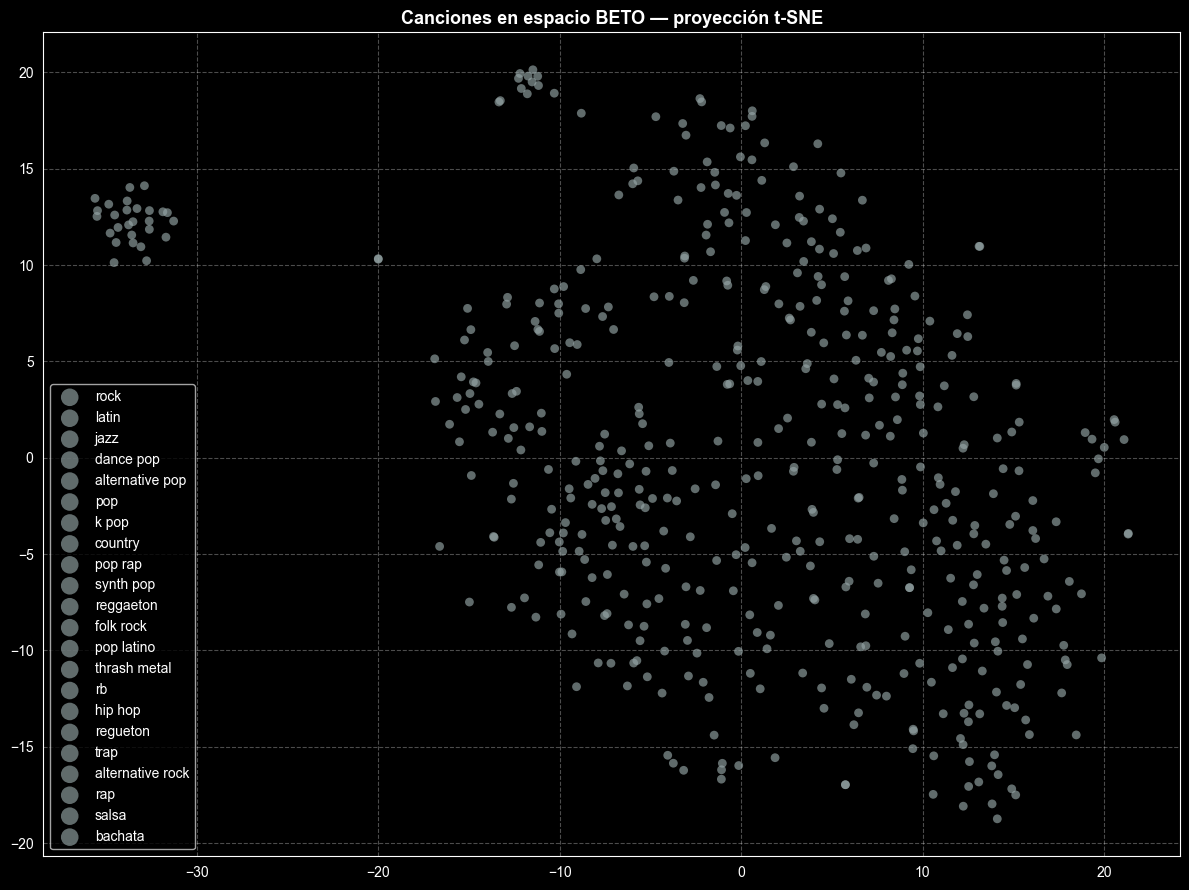

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os  # new edit

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(beto_embeddings)

colores_genero = {
    "Rock": "#e74c3c", "Pop": "#3498db", "Hip-Hop": "#2ecc71",
    "Reggaetón": "#f39c12", "Balada": "#9b59b6"
}

generos_muestra = df_muestra["genero"].fillna("Unknown").tolist()
generos_unicos  = list(set(generos_muestra))

fig, ax = plt.subplots(figsize=(12, 9))
for genero in generos_unicos:
    idx = [i for i, g in enumerate(generos_muestra) if g == genero]
    color = colores_genero.get(genero, "#95a5a6")
    ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], c=color,
               label=genero, s=40, alpha=0.65, edgecolors="none")

ax.set_title("Canciones en espacio BETO — proyección t-SNE",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, markerscale=2)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()

os.makedirs("../docs", exist_ok=True)  # new edit
plt.savefig("../docs/tsne_beto_canciones.png", dpi=150, bbox_inches="tight")  # new edit
# plt.savefig("../docs/tsne_beto_canciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Actualizar embeddings en MongoDB

In [ ]:
from src.embeddings.embeddings_beto import actualizar_beto_cls_mongodb

# Actualiza embeddings.beto_cls para toda la colección
actualizar_beto_cls_mongodb(
    df=df,
    tokenizer=tokenizer,
    model=model,
    col_id="id",
    col_letra="letra",
    batch_size=32,
)
print("beto_cls actualizado en MongoDB.")

Generando embeddings BETO para 6940 canciones...
  Embeddings generados: 160/6940
  Embeddings generados: 320/6940
  Embeddings generados: 480/6940
  Embeddings generados: 640/6940
  Embeddings generados: 800/6940
  Embeddings generados: 960/6940
  Embeddings generados: 1120/6940
  Embeddings generados: 1280/6940
  Embeddings generados: 1440/6940
  Embeddings generados: 1600/6940
  Embeddings generados: 1760/6940
  Embeddings generados: 1920/6940
  Embeddings generados: 2080/6940
  Embeddings generados: 2240/6940
  Embeddings generados: 2400/6940
  Embeddings generados: 2560/6940
  Embeddings generados: 2720/6940
  Embeddings generados: 2880/6940
  Embeddings generados: 3040/6940
  Embeddings generados: 3200/6940
  Embeddings generados: 3360/6940
  Embeddings generados: 3520/6940
  Embeddings generados: 3680/6940
  Embeddings generados: 3840/6940
  Embeddings generados: 4000/6940
  Embeddings generados: 4160/6940
  Embeddings generados: 4320/6940
  Embeddings generados: 4480/6940
  Emb

## 9. Diferencias clave: Word2Vec vs BETO

| Aspecto | Word2Vec | BETO |
|---|---|---|
| Tipo de representación | Estática (1 vector / palabra) | Contextual (vector distinto según contexto) |
| Polisemia | No distingue significados | Vectores distintos para cada uso |
| Dimensión | 100–300d | 768d |
| Velocidad de inferencia | Muy rápida | Lenta (necesita GPU para corpus grandes) |
| Entrenamiento propio | Sí, sobre el corpus propio | No (se usa modelo pre-entrenado) |
| Mejor para | Similitud léxica, analogías sencillas | Comprensión profunda, búsqueda semántica |

**Cuándo usar BETO:** cuando la misma palabra tiene significados distintos según el contexto,
o cuando se necesita capturar el significado de frases completas (búsqueda semántica, clasificación).
